# Chronos-2 — Electricity Load Forecasting
**Darekar, Kim, Saxena | University of Trier | RCS SS2026**

Run cells **top to bottom**. Each section is one scenario from the Exposé.

In [2]:
# Standard library and third-party imports
import sys, os
import warnings
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from chronos import Chronos2Pipeline
from transformers.utils.logging import disable_progress_bar

# Add src/ to path so notebook can import our modules
sys.path.insert(0, os.path.join(os.getcwd(), "src"))
warnings.filterwarnings("ignore")

from config          import RESULTS_DIR, DATA_DIR, MODEL_ID, TARGET_COLUMN, TIMESTAMP_COLUMN
from data_loader     import pan_load, pan_preprocessing, aus_convert_tsf_to_dataframe, aus_preprocessing, lat_load, lat_preprocessing
from metrics         import calculate_metrics, compute_summary_statistics
from plots           import plot_metrics_boxplots, plot_distribution, plot_time_series
from scenarios       import s1_predict, s1_evaluation

print("All imports OK")
print(f"PyTorch  : {torch.__version__}")
print(f"Device   : {'cuda' if torch.cuda.is_available() else 'cpu'}")

All imports OK
PyTorch  : 2.11.0+cpu
Device   : cpu


## 1 — Load and Preprocess Data

1.1. Panama


--- Panama (PAN) Electricity Load Dataset ---
                 datetime  nat_demand    T2M_toc  QV2M_toc   TQL_toc  \
0     2015-01-03 01:00:00    970.3450  25.865259  0.018576  0.016174   
1     2015-01-03 02:00:00    912.1755  25.899255  0.018653  0.016418   
2     2015-01-03 03:00:00    900.2688  25.937280  0.018768  0.015480   
3     2015-01-03 04:00:00    889.9538  25.957544  0.018890  0.016273   
4     2015-01-03 05:00:00    893.6865  25.973840  0.018981  0.017281   
...                   ...         ...        ...       ...       ...   
48043 2020-06-26 20:00:00   1128.5592  27.246545  0.020303  0.055511   
48044 2020-06-26 21:00:00   1112.7488  27.099573  0.020395  0.053848   
48045 2020-06-26 22:00:00   1081.5680  26.971155  0.020448  0.057251   
48046 2020-06-26 23:00:00   1041.6240  26.867487  0.020464  0.064178   
48047 2020-06-27 00:00:00   1013.5683  26.750330  0.020441  0.063965   

         W2M_toc    T2M_san  QV2M_san   TQL_san    W2M_san    T2M_dav  \
0      21.85054

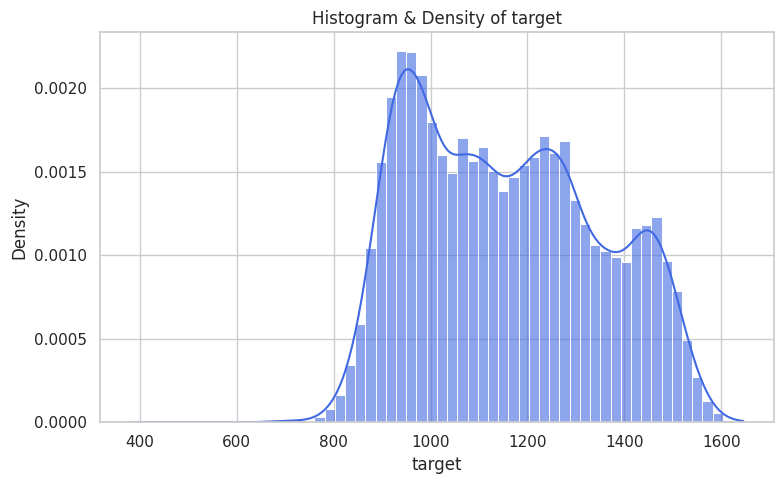

In [3]:
# LOAD & PREPROCESS DATA (Cleaned up via data_loader)
pan_loaded_data = pan_load()  # Uses default continuous_dataset.csv
print("\n--- Panama (PAN) Electricity Load Dataset ---")
print(pan_loaded_data)
pan_preprocessing(pan_loaded_data)

# Display summary statistics and distribution of the target variable
pan_context_df = pd.read_csv(DATA_DIR / "processed" / "pan_context_df.csv")
print("\n--- Target Variable Summary Statistics ---")
deduplicated_pan_context_df = pan_context_df.drop_duplicates(subset=[TIMESTAMP_COLUMN])
print(compute_summary_statistics(deduplicated_pan_context_df, columns=[TARGET_COLUMN]))
plot_distribution(deduplicated_pan_context_df, columns=[TARGET_COLUMN]) # COUNT = (N_DAYS + 7 - 1) * 24

1.2. Australia


--- Australia (AUS) Electricity Load Dataset ---
Loaded Data:   series_name state start_timestamp  \
0          T1   NSW      2002-01-01   
1          T2   VIC      2002-01-01   
2          T3   QUN      2002-01-01   
3          T4    SA      2002-01-01   
4          T5   TAS      2002-01-01   

                                        series_value  
0  [5714.045004, 5360.189078, 5014.835118, 4602.7...  
1  [3535.867064, 3383.499028, 3655.527552, 3510.4...  
2  [3382.041342, 3288.315794, 3172.329022, 3020.3...  
3  [1191.078014, 1219.589472, 1119.173498, 1016.4...  
4  [315.915504, 306.245864, 305.762576, 295.60219...  
Data Frequency: half_hourly
Suggested Forecast Horizon: None
Contains Missing Values?: False
Are all series of Equal Length?: False

[SUCCESS] Preprocessing complete! The dataset is ready to be fed to Chronos-2.

--- Target Variable Summary Statistics ---
              target
count   26424.000000
mean     1312.235475
median   1289.502773
var     90400.458824
min       6

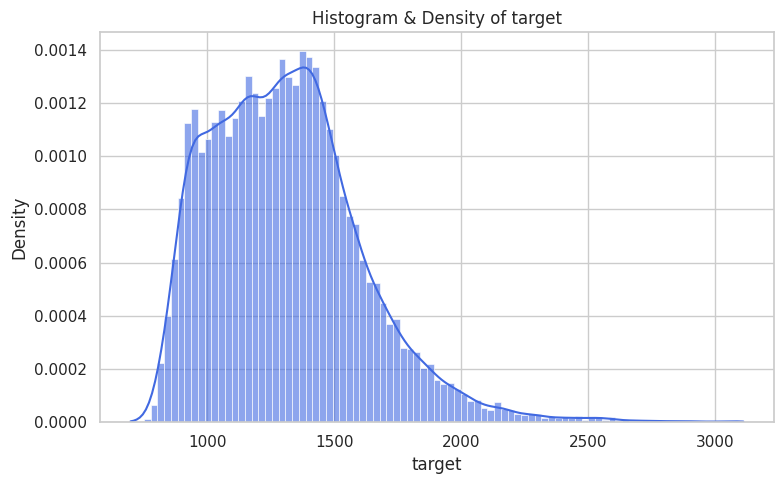

In [4]:
# LOAD & PREPROCESS DATA (Cleaned up via data_loader)
aus_loaded_data, aus_frequency, aus_forecast_horizon, aus_contain_missing_values, aus_contain_equal_length = aus_convert_tsf_to_dataframe(DATA_DIR / "raw" / "australian_electricity_demand_dataset.tsf")

print("\n--- Australia (AUS) Electricity Load Dataset ---")
print(f"Loaded Data: {aus_loaded_data}")
print(f"Data Frequency: {aus_frequency}")
print(f"Suggested Forecast Horizon: {aus_forecast_horizon}")
print(f"Contains Missing Values?: {aus_contain_missing_values}")
print(f"Are all series of Equal Length?: {aus_contain_equal_length}")

aus_preprocessing(aus_loaded_data)

# Display summary statistics and distribution of the target variable
aus_context_df = pd.read_csv(DATA_DIR / "processed" / "aus_context_df.csv")
print("\n--- Target Variable Summary Statistics ---")
deduplicated_aus_context_df = aus_context_df.drop_duplicates(subset=[TIMESTAMP_COLUMN])
print(compute_summary_statistics(deduplicated_aus_context_df, columns=[TARGET_COLUMN]))
plot_distribution(deduplicated_aus_context_df, columns=[TARGET_COLUMN])

1.3. Latvia

No missing entries found in 'target'. Pipeline is clean.

--- Latvia (LAT) Electricity Load Dataset ---
                      timestamp       target
0     2021-01-01 00:00:00+02:00   682.000000
1     2021-01-01 01:00:00+02:00   657.000000
2     2021-01-01 02:00:00+02:00   629.000000
3     2021-01-01 03:00:00+02:00   603.000000
4     2021-01-01 04:00:00+02:00   591.000000
...                         ...          ...
43815 2025-12-31 19:00:00+02:00  1001.418170
43816 2025-12-31 20:00:00+02:00   936.552452
43817 2025-12-31 21:00:00+02:00   905.653516
43818 2025-12-31 22:00:00+02:00   845.028905
43819 2025-12-31 23:00:00+02:00   807.432733

[43820 rows x 2 columns]

[SUCCESS] Preprocessing complete! The dataset is ready to be fed to Chronos-2.

--- Target Variable Summary Statistics ---
              target
count   26424.000000
mean      784.474020
median    781.000000
var     25885.127348
min       423.000000
q1        656.000000
q3        908.000000
max      1237.000000


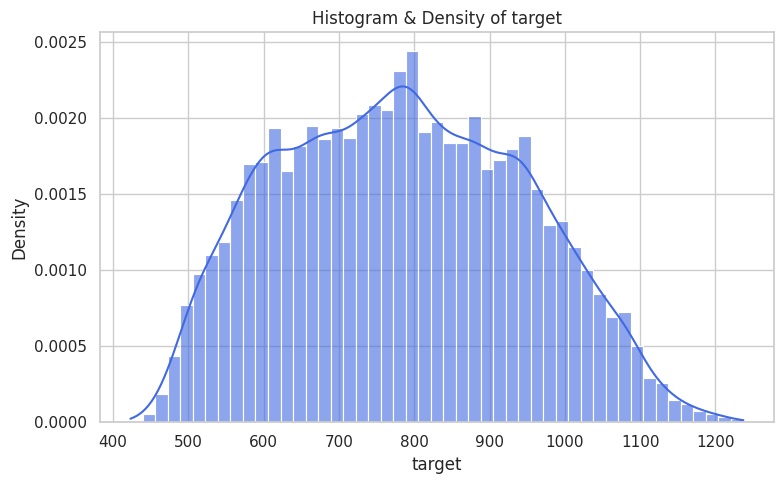

In [5]:
# Load and preprocess data
lat_loaded_data = lat_load()
print("\n--- Latvia (LAT) Electricity Load Dataset ---")
print(lat_loaded_data)
lat_preprocessing(lat_loaded_data)

# Display summary statistics and distribution of the target variable
lat_context_df = pd.read_csv(DATA_DIR / "processed" / "lat_context_df.csv")
print("\n--- Target Variable Summary Statistics ---")
deduplicated_lat_context_df = lat_context_df.drop_duplicates(subset=[TIMESTAMP_COLUMN])
print(compute_summary_statistics(deduplicated_lat_context_df, columns=[TARGET_COLUMN]))
plot_distribution(deduplicated_lat_context_df, columns=[TARGET_COLUMN])

## 2 — Load Chronos-2
Downloads ~700 MB on first run, cached locally after that.

In [6]:
disable_progress_bar()

pipeline = Chronos2Pipeline.from_pretrained(
    MODEL_ID,                     # "amazon/chronos-2"  (set in config.py)
    device_map = "cuda" if torch.cuda.is_available() else "cpu",
    torch_dtype = torch.bfloat16, # use float32 if you get dtype errors on CPU
)

print(f"Loaded {MODEL_ID}")

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loaded amazon/chronos-2


---
## S1 — Univariate Baseline (zero-shot)
Chronos-2 on raw demand only.

Predictions successfully created and saved to '/content/drive/MyDrive/RCS_time_series_forecasting_electric_load/chronos_research/results/pan_pred.csv'.
Metrics successfully created and saved to '/content/drive/MyDrive/RCS_time_series_forecasting_electric_load/chronos_research/results/pan_res.csv'.
Predictions successfully created and saved to '/content/drive/MyDrive/RCS_time_series_forecasting_electric_load/chronos_research/results/aus_pred.csv'.
Metrics successfully created and saved to '/content/drive/MyDrive/RCS_time_series_forecasting_electric_load/chronos_research/results/aus_res.csv'.
Predictions successfully created and saved to '/content/drive/MyDrive/RCS_time_series_forecasting_electric_load/chronos_research/results/lat_pred.csv'.
Metrics successfully created and saved to '/content/drive/MyDrive/RCS_time_series_forecasting_electric_load/chronos_research/results/lat_res.csv'.


--- Panama (PAN) Electricity Load Time Series Forecasting Plot ---


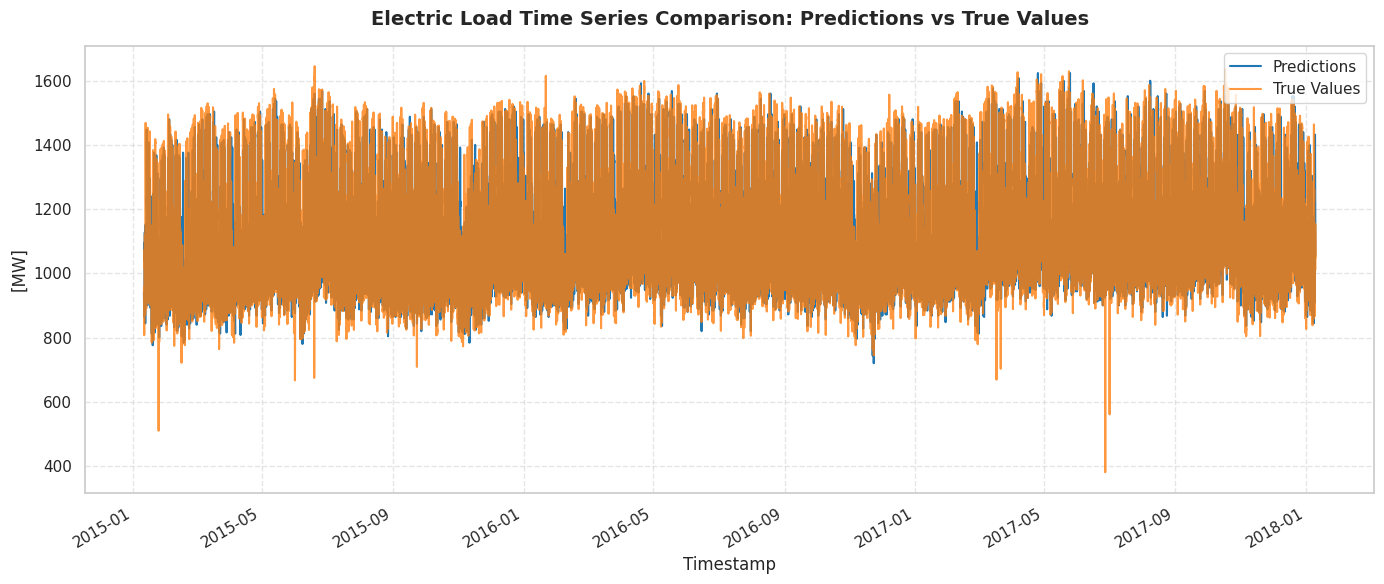

Plot successfully created and saved to '/content/drive/MyDrive/RCS_time_series_forecasting_electric_load/chronos_research/results/pan_time_series.png'.


--- Australia (AUS) Electricity Load Time Series Forecasting Plot ---


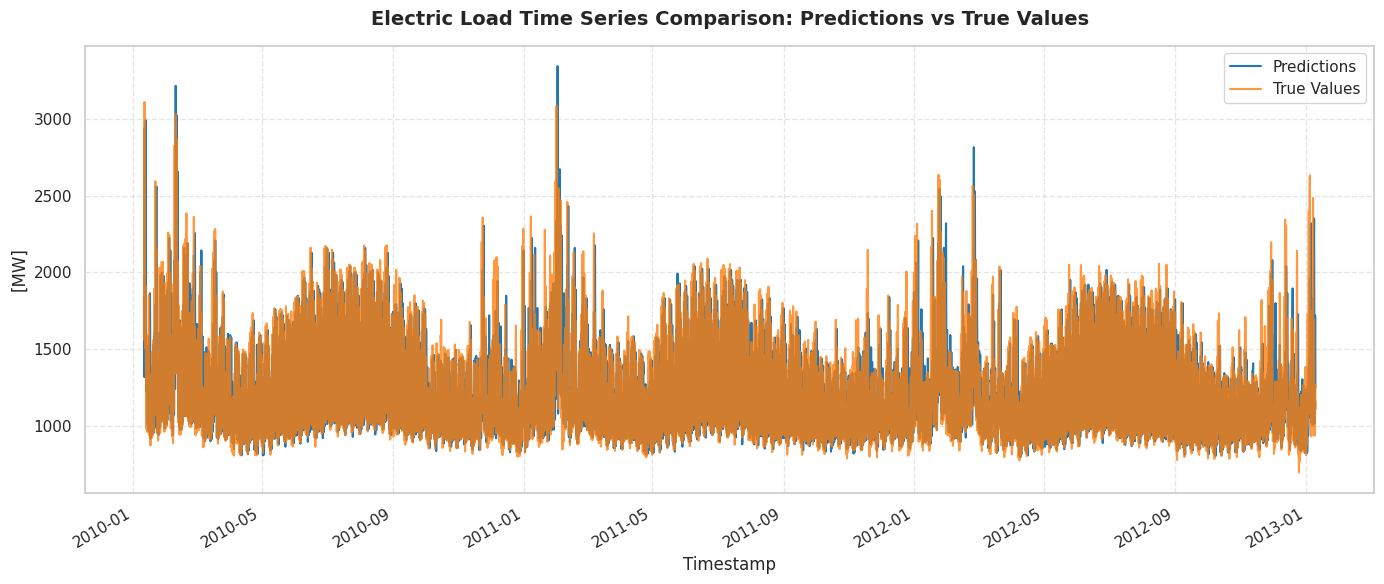

Plot successfully created and saved to '/content/drive/MyDrive/RCS_time_series_forecasting_electric_load/chronos_research/results/aus_time_series.png'.


--- Latvia (LAT) Electricity Load Time Series Forecasting Plot ---


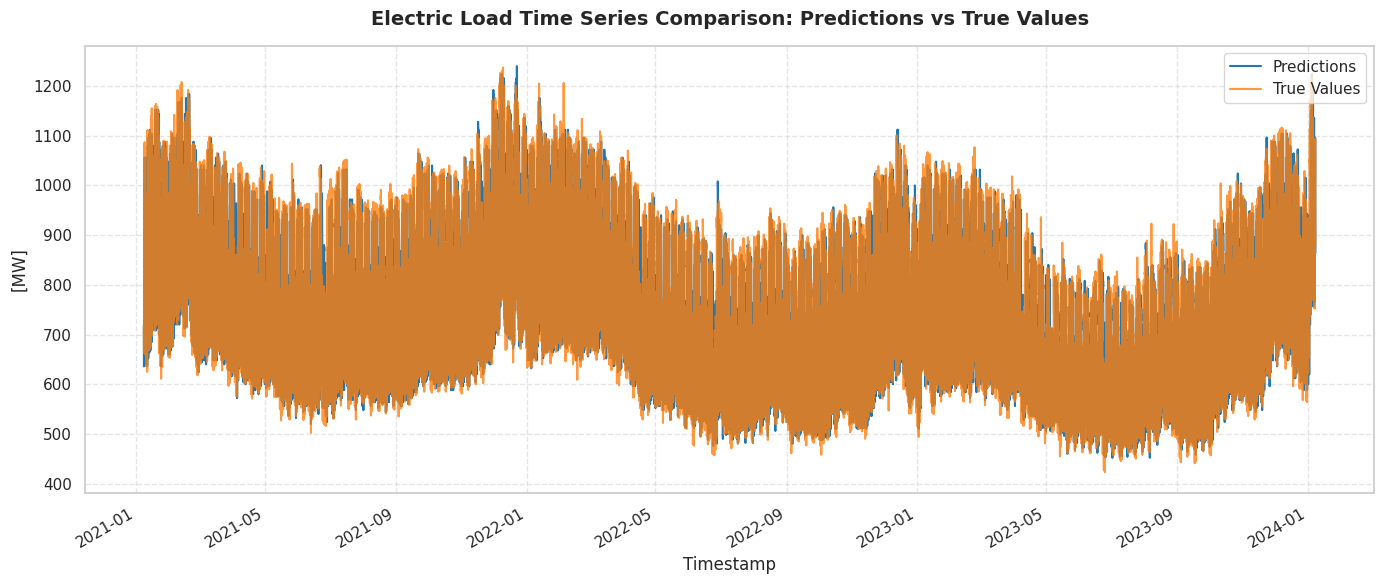

Plot successfully created and saved to '/content/drive/MyDrive/RCS_time_series_forecasting_electric_load/chronos_research/results/lat_time_series.png'.


In [7]:
# Predict electric load and evaluate the result
pan_context_df = pd.read_csv(DATA_DIR / "processed" / "pan_context_df.csv")
pan_ground_truth = np.load(DATA_DIR / "processed" / "pan_horizon_true.npy")

aus_context_df = pd.read_csv(DATA_DIR / "processed" / "aus_context_df.csv")
aus_ground_truth = np.load(DATA_DIR / "processed" / "aus_horizon_true.npy")

lat_context_df = pd.read_csv(DATA_DIR / "processed" / "lat_context_df.csv")
lat_ground_truth = np.load(DATA_DIR / "processed" / "lat_horizon_true.npy")

pan_pred = s1_predict(pipeline, pan_context_df, save_path = RESULTS_DIR / "pan_pred.csv")
pan_res = s1_evaluation(pan_pred, pan_ground_truth, save_path = RESULTS_DIR / "pan_res.csv")

aus_pred = s1_predict(pipeline, aus_context_df, save_path = RESULTS_DIR / "aus_pred.csv")
aus_res = s1_evaluation(aus_pred, aus_ground_truth, save_path = RESULTS_DIR / "aus_res.csv")

lat_pred = s1_predict(pipeline, lat_context_df, save_path = RESULTS_DIR / "lat_pred.csv")
lat_res = s1_evaluation(lat_pred, lat_ground_truth, save_path = RESULTS_DIR / "lat_res.csv")
print("\n")

print("--- Panama (PAN) Electricity Load Time Series Forecasting Plot ---")
plot_time_series(pan_pred, pan_ground_truth, RESULTS_DIR / "pan_time_series.png")
print("\n")

print("--- Australia (AUS) Electricity Load Time Series Forecasting Plot ---")
plot_time_series(aus_pred, aus_ground_truth, RESULTS_DIR / "aus_time_series.png")
print("\n")

print("--- Latvia (LAT) Electricity Load Time Series Forecasting Plot ---")
plot_time_series(lat_pred, lat_ground_truth, RESULTS_DIR / "lat_time_series.png")

--- Panama (PAN) Electricity Load Forecasting Accuracy Metrics (RMSE and MAPE): Summary Statistics ---
               rmse         mape
count   1095.000000  1095.000000
mean      51.253536     3.548808
median    38.102233     2.644769
var     1755.283241     8.537140
min       10.628183     0.657950
q1        26.458802     1.845917
q3        56.733437     4.050132
max      299.057792    23.428759


--- Australia (AUS) Electricity Load Forecasting Accuracy Metrics (RMSE and MAPE): Summary Statistics ---
               rmse         mape
count   1095.000000  1095.000000
mean     103.580980     6.004704
median    70.236560     4.153724
var     9833.744937    29.025880
min        9.394003     0.640214
q1        45.409314     2.760654
q3       122.612995     7.268960
max      870.514888    46.304512


--- Latvia (LAT) Electricity Load Forecasting Accuracy Metrics (RMSE and MAPE): Summary Statistics ---
               rmse         mape
count   1095.000000  1095.000000
mean      27.598516     

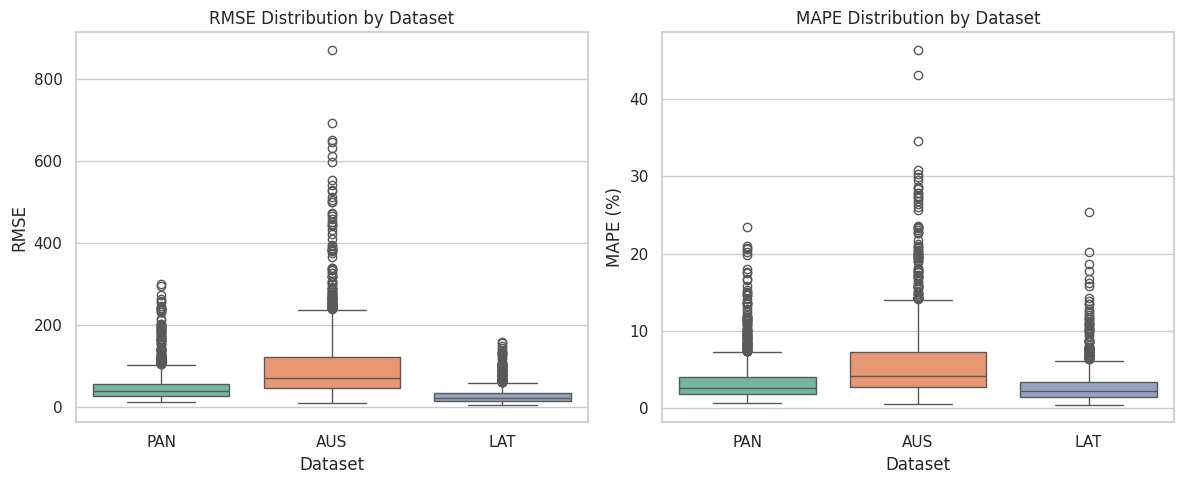

Box plots successfully created and saved.


In [9]:
# Display Summary Statistics of the resulting Accuracy Metrics
print("--- Panama (PAN) Electricity Load Forecasting Accuracy Metrics (RMSE and MAPE): Summary Statistics ---")
print(compute_summary_statistics(pan_res, columns=['rmse', 'mape']))
print("\n")
print("--- Australia (AUS) Electricity Load Forecasting Accuracy Metrics (RMSE and MAPE): Summary Statistics ---")
print(compute_summary_statistics(aus_res, columns=['rmse', 'mape']))
print("\n")
print("--- Latvia (LAT) Electricity Load Forecasting Accuracy Metrics (RMSE and MAPE): Summary Statistics ---")
print(compute_summary_statistics(lat_res, columns=['rmse', 'mape']))

# Combine pan_res, aus_res, and lat_res vertically
merged_res_df = pd.concat([pan_res, aus_res, lat_res], ignore_index=True)

# Make summary boxplots
plot_metrics_boxplots(merged_res_df)

---
## S2 — Covariate-Informed Forecasting
Weather (T2M, QV2M, W2M, PS) + calendar features via `predict_df(future_df=...)`

---
## S3a — Cross-City Learning
Feed per-city temperature series (Tocumen, Santiago, David) alongside national demand.

---
## S3b — STL Decomposition Cross-Learning
Decompose demand → trend + seasonal (24 h) + residual, feed all as separate series.

---
## S4 — Ensemble-Based Forecasting
10 weather realisations → average (mirrors Copernicus ERA5 EDA)

---
## Results Summary